## Dataframe Setup

In [870]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [871]:
dates = ['Intake_Date', 'Outcome_Date', 'DOB']
dtypes = {
    'Outcome_Type': 'category',
    'Intake_Age': 'object',
    'Outcome_Age': 'object',
    'Animal_Type': 'category',
    'Breed': 'object',
    'Primary_Color': 'category',
    'Secondary_Color': 'category',
    'Intake_Condition': 'category',
    'Intake_Type': 'category',
    'Sex': 'category',
    'Days_in_Shelter': 'float64',
    'Shelter_Name': 'object',
}

Long_Beach_Animal_Data = pd.read_csv('Long_Beach_Animal_Data.csv')
print("Long Beach Animals" , Long_Beach_Animal_Data.shape)
Sonoma_Animal_Data = pd.read_csv('Sonoma_Animal_Data.csv')
print("Sonoma County Animals" , Sonoma_Animal_Data.shape)
Austin_Animal_Data = pd.read_csv('Austin_Animal_Data.csv', dtype= dtypes, parse_dates=dates)
print("Austin Animals" , Austin_Animal_Data.shape)

animal_data = pd.concat([Long_Beach_Animal_Data, Austin_Animal_Data, Sonoma_Animal_Data])

animal_data = animal_data.astype(
        {
        'Outcome_Type' : 'category',
        'Intake_Type' : 'category',
        'Intake_Age' : 'float64',
        'Outcome_Age' : 'object',
        'Animal_Type' : 'category',
        'Breed' : 'object',
        'Primary_Color' : 'category',
        'Secondary_Color' : 'object',
        'Intake_Condition' : 'category',
        'Sex' : 'category',
        'Intake_Date' : 'datetime64[ns]',
        'Outcome_Date' : 'datetime64[ns]',
        'Days_in_Shelter' : 'object',
        'Shelter_Name' : 'object'
    }
)


Long Beach Animals (24718, 15)
Sonoma County Animals (18900, 15)
Austin Animals (77896, 15)


## Dataset Features Overview

In [718]:
print(f"Missing values:\n {animal_data.isna().sum()}\n")

print(f"\nDuplicated Values: {animal_data.duplicated().sum()}\n")
animal_data = animal_data.drop_duplicates()
print("\nDuplicated Values Dropped\n")
animal_data = animal_data.reset_index(drop=True)

print(f'Shape: {animal_data.shape}\n')

print(f"Unique Values\n {animal_data.nunique()}\n")

animal_data.describe()

Missing values:
 Animal_Type             0
DOB                     0
Primary_Color           0
Secondary_Color     58181
Sex                     0
Intake_Date             0
Intake_Condition        0
Intake_Type             0
Outcome_Date            0
Outcome_Type            0
Intake_Age              0
Outcome_Age             0
Days_in_Shelter         0
Breed                   0
Shelter_Name            0
dtype: int64


Duplicated Values: 0


Duplicated Values Dropped

Shape: (121514, 15)

Unique Values
 Animal_Type            13
DOB                 13294
Primary_Color         142
Secondary_Color       107
Sex                     9
Intake_Date         60584
Intake_Condition       30
Intake_Type            21
Outcome_Date        69012
Outcome_Type           31
Intake_Age           4231
Outcome_Age          4509
Days_in_Shelter       864
Breed                3104
Shelter_Name            3
dtype: int64



,Intake_Date,Outcome_Date,Intake_Age
count,121514,121514,121514.000000
mean,2017-04-12 20:25:45.914709504,2017-05-01 11:58:59.356617472,836.100268
min,2013-08-16 00:00:00,2013-10-01 10:39:00,-1336.000000
25%,2015-04-21 09:49:30,2015-05-07 00:00:00,2.000000
50%,2016-09-27 10:57:00,2016-10-19 11:42:30,270.000000
75%,2018-02-17 13:37:00,2018-03-02 00:00:00,1095.000000
max,2025-01-12 00:00:00,2025-01-13 00:00:00,10957.000000
std,NaN,NaN,1199.563544


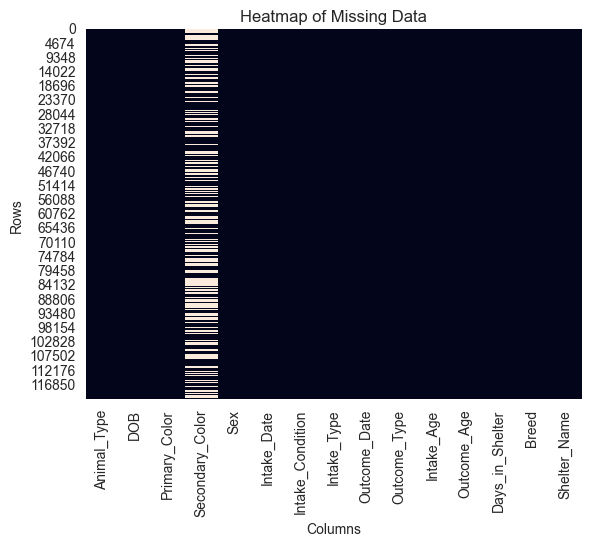

In [719]:
sns.heatmap(animal_data.isnull(), cbar=False)
plt.title("Heatmap of Missing Data")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

## Animal Type
Records are simplified and grouped into either Cat, Dog, or Other. <br>
Count-plot of Category Distribution.

In [720]:
def Simplify_Type(animal):
    map = {
        "Rabbit" : "Other",
        "Wild" : "Other",
        "Guinea Pig" : "Other",
        "Livestock" : "Other",
        "Bird" : "Other",
        "Reptile" : "Other"
    }
    return map.get(animal, animal.title())

animal_data['Animal_Type'] = animal_data['Animal_Type'].apply(Simplify_Type)

### Animal Type - Histogram

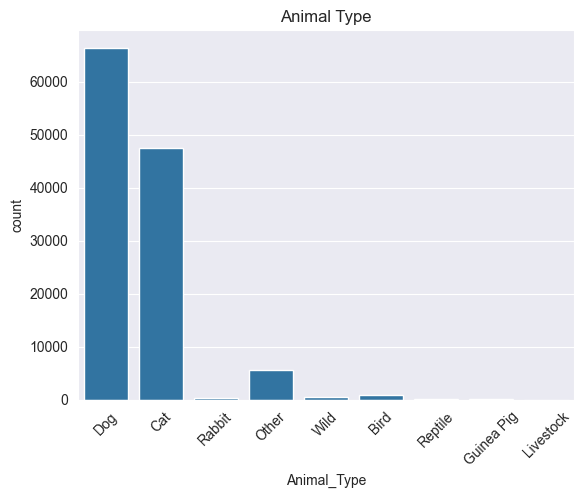

In [721]:
ax = sns.countplot(data=animal_data, x='Animal_Type')
ax.tick_params(axis='x', rotation=45)
ax.set_title("Animal Type")
plt.show()

## Intake & Outcome Age

Filtering of dates to only have non-negative datetime. <br>
Transformations to create a daily, monthly, and yearly age value. <br>
Also, standardizing the time format.

Long Beach, CA - 2017-01-01 -> 2025-01-13 <br>
Sonoma County, CA - 2013-08-16 -> 2023-09-23 <br>
Austin, TX - 2013-10-01 -> 2018-04-03

In [722]:
def Simplify_Datetime(text):
    if isinstance(text, str) and ' ' in text:
        num, time = text.split(" ")
        num = int(num)
        if time.lower() == 'days':
            return num
        if time.lower() == 'months':
            return int(round(num * 30.44))
        if time.lower() == 'years':
            return int(round(num * 365.25))
    elif isinstance(text, (int, float)):
        return float(text)
    return 0

animal_data['Outcome_Age_Days'] = animal_data['Outcome_Age'].apply(Simplify_Datetime)
animal_data['Outcome_Age_Days'] = animal_data['Outcome_Age_Days'].astype('float64')
animal_data['Intake_Age_Days'] = animal_data['Intake_Age'].apply(Simplify_Datetime)
animal_data['Intake_Age_Days'] = animal_data['Intake_Age_Days'].astype('float64')

animal_data = animal_data[(animal_data['Intake_Age_Days'] > 0) & (animal_data['Outcome_Age_Days'] > 0)]

animal_data['Outcome_Age_Years'] = animal_data['Outcome_Age_Days'].astype(int).apply(lambda x : round((x / 365.25), 1))
animal_data['Intake_Age_Years'] = animal_data['Intake_Age_Days'].astype(int).apply(lambda x : round((x /  365.25), 1))

### Animal Ages - Histograms

#### Animal Intake Age (Years)

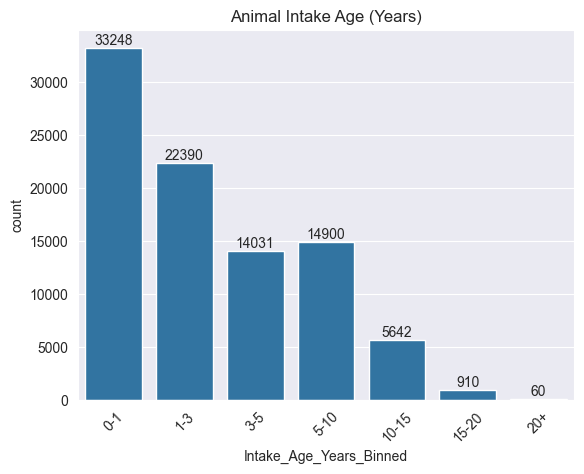

In [723]:
bins = [0, 1, 3, 5, 10, 15, 20, 100]
labels = ['0-1', '1-3', '3-5', '5-10', '10-15', '15-20', '20+']
animal_data['Intake_Age_Years_Binned'] = pd.cut(animal_data['Intake_Age_Years'], bins=bins, labels=labels, right=False)

ax = sns.countplot(data=animal_data, x='Intake_Age_Years_Binned')
ax.set_title("Animal Intake Age (Years)")
plt.xticks(rotation=45)

for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{count}', (x, y), ha='center', va='bottom')

plt.show()

#### Animal Outcome Age (Years)

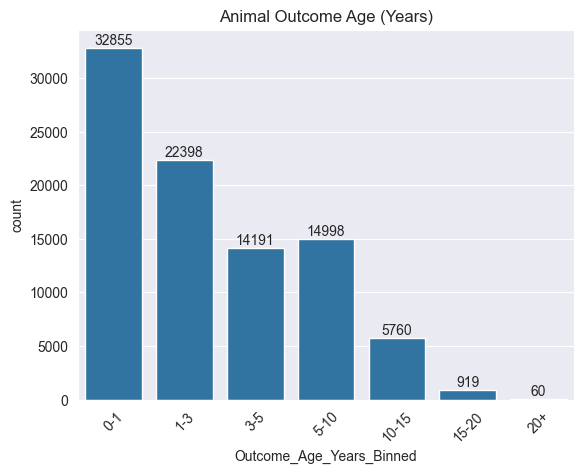

In [724]:
bins = [0, 1, 3, 5, 10, 15, 20, 100]
labels = ['0-1', '1-3', '3-5', '5-10', '10-15', '15-20', '20+']
animal_data['Outcome_Age_Years_Binned'] = pd.cut(animal_data['Outcome_Age_Years'], bins=bins, labels=labels, right=False)

ax = sns.countplot(data=animal_data, x='Outcome_Age_Years_Binned')
ax.set_title("Animal Outcome Age (Years)")
plt.xticks(rotation=45)

for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{count}', (x, y), ha='center', va='bottom')

plt.show()

#### Intake by Year Visualizations

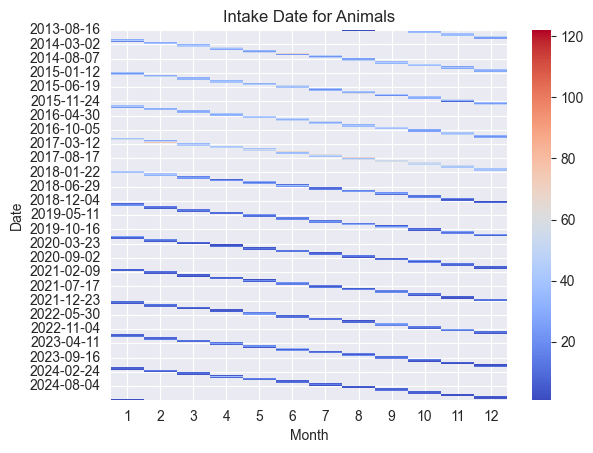

In [725]:
animal_data['Intake_Date_Available'] = animal_data['Intake_Date'].notnull()

heatmap_data = animal_data.pivot_table(
    index=animal_data['Intake_Date'].dt.date,
    columns=animal_data['Intake_Date'].dt.month,
    values='Intake_Date_Available',
    aggfunc='count'
)
animal_data.drop(columns='Intake_Date_Available')
sns.heatmap(heatmap_data, cmap="coolwarm", cbar=True)
plt.title("Intake Date for Animals")
plt.xlabel("Month")
plt.ylabel("Date")
plt.show()

#### Outcome Date by Year Visualization

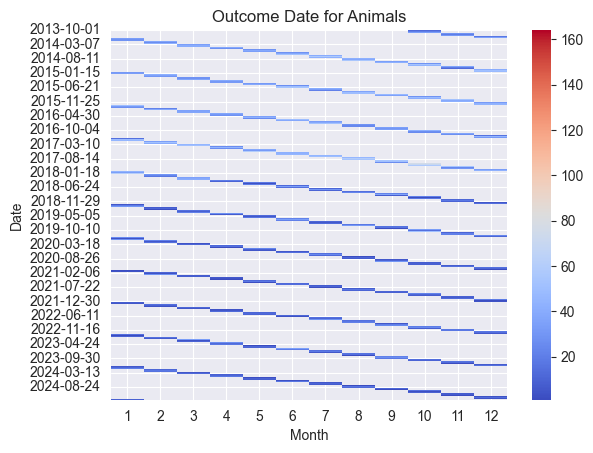

In [726]:
animal_data['Outcome_Date_Available'] = animal_data['Outcome_Date'].notnull()

heatmap_data = animal_data.pivot_table(
    index=animal_data['Outcome_Date'].dt.date,
    columns=animal_data['Outcome_Date'].dt.month,
    values='Outcome_Date_Available',
    aggfunc='count'
)
animal_data.drop(columns='Outcome_Date_Available')
sns.heatmap(heatmap_data, cmap="coolwarm", cbar=True)
plt.title("Outcome Date for Animals")
plt.xlabel("Month")
plt.ylabel("Date")
plt.show()

## Intake & Outcome Types
Filtering of Types to exclude outliers <br>
Transformations of existing categories to simple terms <br>

In [727]:
def Simplify_Intake_Type(intake):
    intakes = {
        "Transfer" : "Transfer/Return",
        "Return" : "Transfer/Return",
        "Adopted Animal Return" : "Transfer/Return",
        "Adoption Return" : "Transfer/Return",
        'Euthenasia Required' : "Euthanasia",
        "Euthanasia Request" : "Euthanasia",
        "Trap, Neuter, Return" : "Neuter",
        "Born Here" : "Stray",
        "Confiscate" : "Public Assist",
        "Welfare Seized" : "Public Assist",
        "Foster" : "Public Assist",
        "Wildlife" : "Public Assist",
        "Safe Keep" : "Public Assist"
    }

    return intakes.get(intake, intake).title()

animal_data = animal_data[(animal_data['Intake_Type'] != 'Os Appt')] # Filter
animal_data['Intake_Type'] = animal_data['Intake_Type'].apply(Simplify_Intake_Type)

In [728]:
def Simplify_Outcome_Type(outcome):
    outcomes = {
        "Disposal" : "Died",
        "Shelter, Neuter, Return" : "Neuter & Release",
        "Trap, Neuter, Release" : "Neuter & Release",
        "Rtos" : "Return To Owner",
        "Rto-Adopt" : "Return to Owner",
        "Missing" : "Missing/Escaped",
        "Escaped/Stolen" : "Missing/Escaped",
        "Euthanize" : "Euthanasia",
        "Homefirst" : "Adoption",
        "Community Cat" : "Adoption",
        "Foster To Adopt" : "Transfer",
        "Transport" : "Transfer",
        "Rescue" : "Transfer",
        "Return To Rescue" : "Transfer",
        "Foster" : "Transfer",
        "Relocate" : "Transfer"
    }
    return outcomes.get(outcome,outcome).title()


animal_data = animal_data[~animal_data['Outcome_Type'].isin(['Duplicate', 'Return To Wild Habitat', 'Unknown'])] # Filter
animal_data['Outcome_Type'] = animal_data['Outcome_Type'].apply(Simplify_Outcome_Type)

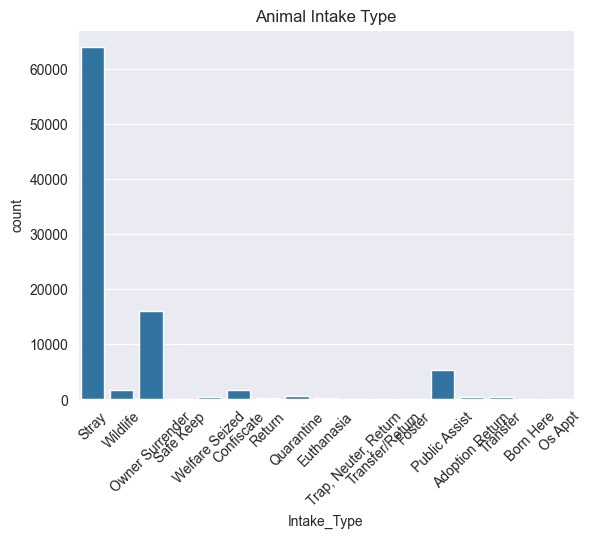

In [729]:
ax = sns.countplot(data=animal_data, x='Intake_Type')
ax.set_title("Animal Intake Type")
ax.tick_params(axis='x', rotation=45)
plt.show()

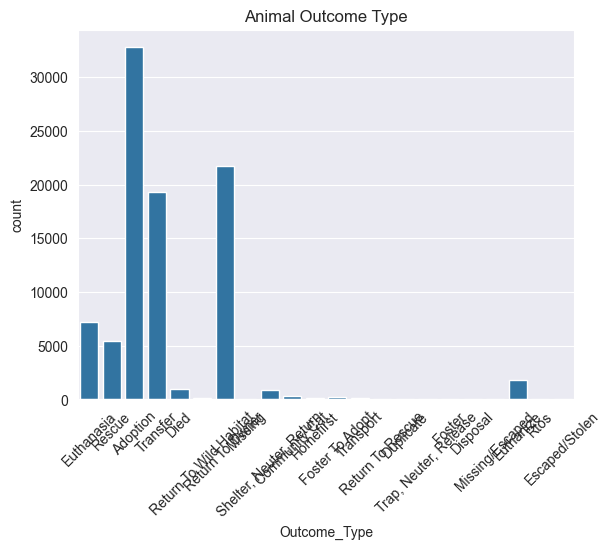

In [730]:
ax = sns.countplot(data=animal_data, x='Outcome_Type')
ax.set_title("Animal Outcome Type")
ax.tick_params(axis='x', rotation=45)
plt.show()

## Intake Condition
Filtering of Types to exclude outliers <br>
Transformations of existing categories to simple terms <br>


In [731]:
def Simplify_Intake_Condtion(condition):
    conditions = {
        "Pregnant" : "Pregnant/Nursing",
        "Nursing" : "Pregnant/Nursing",
        "Injured" : "Injured/Sick",
        "Sick" : "Injured/Sick",
        "Treatable/Rehab" : "Injured/Sick",
        "Treatable/Manageable" : "Injured/Sick",
        "Ill Mild" : "Injured/Sick", 
        "Ill Moderatete" : "Injured/Sick",
        "Ill Severe" : "Injured/Sick",
        "Injured Mild" : "Injured/Sick",
        "Injured  Mild" : "Injured/Sick",
        "Injured Modereate" : "Injured/Sick",
        "Injured  Modereate" : "Injured/Sick",
        "Injured  Moderate" : "Injured/Sick",
        "Injured Severe" : "Injured/Sick",
        "Injured  Severe" : "Injured/Sick",
        "Underage/Weight" : "Injured/Sick",
        "Intakeexam" : "Injured/Sick",
        "Welfare Seizures" : "Injured/Sick",
        "I/I Report" : "Injured/Sick",
        "Untreatable" : "Injured/Sick",
        "Aged" : "Healthy",
        "Behavior  Moderate" : "Healthy",
        "Behavior  Severe" : "Healthy",
        "Behavior  Mild" : "Healthy",
        "Fractious" : "Healthy",
        "Normal" : "Healthy",
        "Feral" : "Other",
        'Under Age/Weight' : "Injured/Sick"
    }
    return conditions.get(condition,condition).title()

animal_data['Intake_Condition'] = animal_data['Intake_Condition'].apply(Simplify_Intake_Condtion)

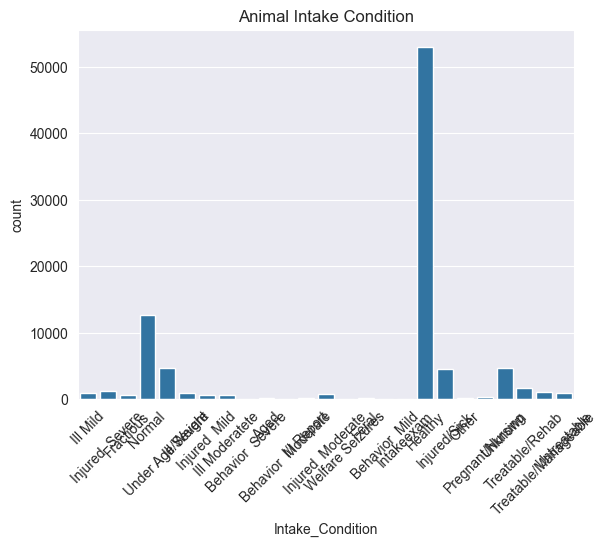

In [732]:
ax = sns.countplot(data=animal_data, x='Intake_Condition')
ax.set_title("Animal Intake Condition")
ax.tick_params(axis='x', rotation=45)
plt.show()

## Breed
Transformations of existing categories to simpler

In [889]:
def Simplify_Breed(animal):
    abbreviations = {
        "Retr": "Retriever",
        "Pinsch": "Pinscher",
        "Terr": "Terrier",
        "Pbgv": "Petit Basset Griffon Vendéen",
        "Germ Shepherd" : "German Shepherd",
        "Domestic Sh" : "Domestic Shorthair",
        'Chihuahua Sh' : 'Chihuahua Shorthair',
        "Labrador Retr" : "Labrador Retriever",
        "Lab" : "Labrador Retriever",
        "Labrador" : "Labrador Retriever",
        "Domestic Mh" : "Domestic Medium Hair",
        "Domestic Lh" : "Domestic Long Hair",
        "Domestic Longhair" : "Domestic Long Hair",
        'Yorkshire Terri' : 'Yorkshire Terrier',
        'Yorkshire Terr' : 'Yorkshire Terrier',
        'Fox Terr Wire' : 'Wire Hair Fox Terrier',
        'Tibetan Terr' : 'Tibetan Terrier',
        'Scottish Terr' : 'Scottish Terrier',
        'Airedale Terr' : 'Airedale Terrier',
        'Manchester Terr' : 'Manchester Terrier',
        'Fox Terr Smooth' :  'Smooth Fox Terrier',
        'Aust Terrier' : "Australian Terrier",
        'Sc Wheat Terr' : 'Soft Coated Wheaten Terrier',
        'Mex Hairless' : 'Mexican Hairless',
        'Eng Pointer' : 'English Pointer',
        'Poodle Toy' : 'Toy Poodle',
        'Poodle Min' : 'Miniature Poodle',
        'Poodle Stnd' : 'Standard Poodle',
        'Border Collie X' : 'Border Collie',
        'Exotic Sh' : "Exotic Shorthair",
        "Munchkin Sh" :"Munchkin Shorthair",
        "Germ Sh Point" : "German Shorthair Pointer",
        "British Sh" : "British Shorthair",
        'Oldeng Sheepdog' : "Old English Sheepdog",
        'Aust Shepherd' : "Australian Shepherd",
        'Aust Cattle Dog' : 'Australian Cattle Dog',
        'Aust Kelpie' : "Australian Kelpie",
        'Germ Wh Point' : 'German Wirehaired Pointer',
        'Bedlington Terr' : "Bedlington Terrier",
        'Patterdale Terr' : "Patterdale Terrier",
        'Sealyham Terr' : "Sealyham Terrier",
        'Chihuahua X' : 'Chihuahua',
        'Chihuahua Lh' : 'Chihuahua Longhair',
        'Min Pinscher' : 'Miniature Pinscher',
        'Welsh Corgi Pem' : 'Pembroke Welsh Corgi',
        'Welsh Corgi Car' : 'Cardigan Welsh Corgi',
        'Dachshund Wh' : 'Dachshund Wirehair',
        'Dachshund Lh' : 'Dachshund Longhair',
        'Dachshund Stan' : 'Dachshund',
        'Eng Coonhound' : 'English Coonhound',
        'Ital Greyhound' : 'Italian Greyhound',
        'Amer Foxhound' : 'American Foxhound',
        'Scot Deerhound' : "Scottish Deerhound",
        'Tr Walker Hound' : 'Treeing Walker Coonhound',
        'Norw Elkhound' : 'Norwegian Elkhound',
        'Eng Foxhound' : 'English Foxhound',
        'Lop-Amer Fuzzy' : 'American Fuzzy Lop',
        'Amer Bulldog' : "American Bulldog",
        'Pitt Bull' : 'Pit Bull',
        'Am Pit Bull Ter' : 'American Pit Bull Terrier',
        'Chesa Bay Retr': 'Chesa Bay Retriever',
        'Golden Retr' : 'Golden Retriever',
        'Schnauzer Min' : 'Miniature Schnauzer',
        'Cocker Span' : 'Cocker Spaniel',
        'Eng Sprngr Span' : 'English Springer Spaniel',
        'Tibetan Span' : 'Tibetan Spaniel',
        'Clumber Span' : 'Clumber Spaniel',
        'Sussex Span' : 'Sussex Spaniel',
        'Boykin Span' : 'Boykin Spaniel',
        'Eng Toy Spanel' : 'English Toy Spaniel',
        'Flat Coat Retr' : 'Flat Coat Retriever',
        'Cavalier Span' : "Cavalier Spaniel",
        'American Staff' : 'American Staffordshire Terrier',
        'Amer Eskimo' : 'American Eskimo',
        'Chinchilla-Amer' : 'Chinchilla-American',
        'Eng Bulldog' : 'English Bulldog',
        'Old Eng Bulldog' : 'Old English Bulldog',
        'Eng Setter' : 'English Setter',
        'Eng Toy Spaniel' : 'English Toy Spaniel',
        'Queensland Hell' : 'Queensland Heller'
    }
    if animal is not None:
        animal = animal.replace("Mix", "").strip()
        return abbreviations.get(animal, animal).title()
    else:
        return None

animal_data[['Primary_Breed', 'Secondary_Breed', 'Tertiary_Breed']] = animal_data['Breed'].str.split(r"[&/]+", expand=True)
animal_data[['Secondary_Breed','Tertiary_Breed']] = animal_data[['Secondary_Breed','Tertiary_Breed']].fillna('None')

837


In [890]:
animal_data['Primary_Breed'] = animal_data['Primary_Breed'].apply(Simplify_Breed)
animal_data['Secondary_Breed'] = animal_data['Secondary_Breed'].apply(Simplify_Breed)
animal_data['Tertiary_Breed'] = animal_data['Tertiary_Breed'].apply(Simplify_Breed)

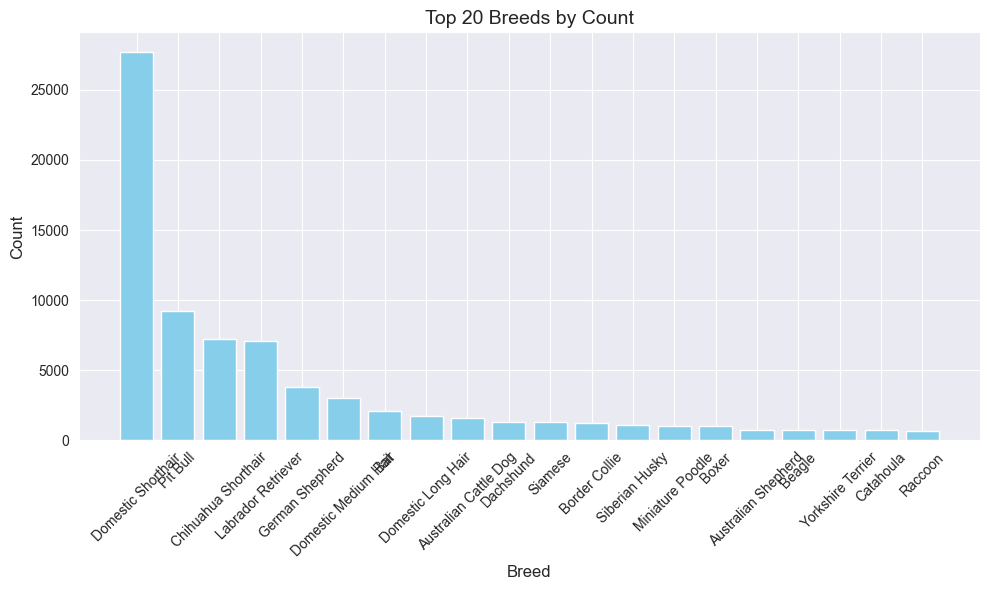

Index(['Silky Terrier', 'Scottish Terrier', 'Australian Terrier',
       'German Wirehaired Pointer', 'English Foxhound', 'Newfoundland',
       'Irish Terrier', 'Bengal', 'Lionhead', 'Rabbit Lh', 'Lop-Mini', 'Snake',
       'St. Bernard Smooth Coat', 'Dutch', 'Duck', 'Pigeon', 'Lop-Holland',
       'Schipperke', 'Patterdale Terrier', 'Feist', 'Dogue De Bordeaux',
       'Lop-English', 'Dove', 'Schnauzer Giant', 'Samoyed', 'Turtle', 'Havana',
       'Chinese Crested', 'American', 'Leonberger', 'Hotot',
       'Old English Bulldog', 'Akbash', 'New Zealand Wht', 'Cockatiel',
       'American Curl Shorthair', 'Alask Malamute', 'Welsh Terrier',
       'Shetld Sheepdog', 'Coyote', 'Landseer', 'Angora', 'Bearded Collie',
       'Goat', 'Swedish Vallhund', 'Abyssinian', 'Field Spaniel',
       'Irish Wolfhound', 'Grackle', 'Balinese'],
      dtype='object', name='Primary_Breed')


In [891]:
filtered_df = animal_data[animal_data['Primary_Breed'] != 'Unknown']
breed_count = filtered_df['Primary_Breed'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(x=breed_count.index[:20], height=breed_count.values[:20], color='skyblue')
plt.title('Top 20 Breeds by Count', fontsize=14)
plt.xlabel('Breed', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(breed_count.index[150:200])

## Sex
Filtering of Types to exclude outliers <br>
Transformations of existing categories to simplify terms <br>

In [736]:
def Simplify_Sex(animal):
    map = {
        "Female" : "Intact Female",
        "Male" : "Intact Male",
        "Spayed" : "Spayed Female",
        "Neutered" : "Neutered Male"
    }
    return map.get(animal, animal)

animal_data['Sex'] = animal_data["Sex"].apply(Simplify_Sex)

animal_data['Sex'].value_counts()

Sex
Neutered Male    23436
Intact Male      22019
Spayed Female    20107
Intact Female    19903
Unknown           5710
Name: count, dtype: int64

## Days in Shelter

Transformations of existing categories to have one formatted date


In [737]:
def Simplify_Days_In_Shelter(date):
    if isinstance(date, str) and ' ' in date:
        num, _ = date.split(' ')
        return int(num)

animal_data['Days_in_Shelter'] = animal_data['Days_in_Shelter'].apply(Simplify_Days_In_Shelter)

In [738]:
animal_data.to_csv('Animal_Adoptions.csv')

PermissionError: [Errno 13] Permission denied: 'Animal_Adoptions.csv'